PCA of GEMINI Embedding

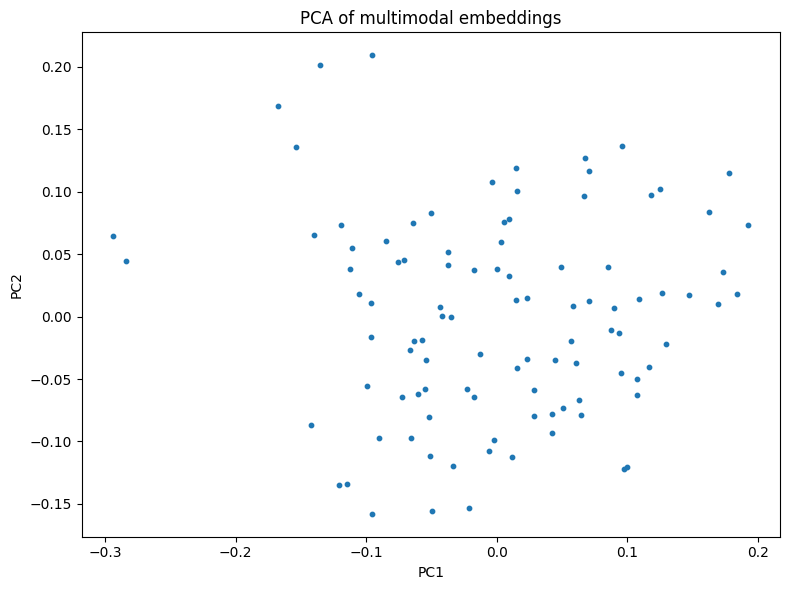

In [6]:
import matplotlib.pyplot as plt
import torch

PATH = "multimodal_embeddings_gemini_2.pt"

data = torch.load(PATH, map_location="cpu")
embeddings = data["embeddings"].float()

# PCA to 2D
centered = embeddings - embeddings.mean(dim=0, keepdim=True)
_, _, v = torch.pca_lowrank(centered, q=2)
points_2d = centered @ v[:, :2]

plt.figure(figsize=(8, 6))
plt.scatter(points_2d[:, 0].numpy(), points_2d[:, 1].numpy(), s=10)
plt.title("PCA of multimodal embeddings")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

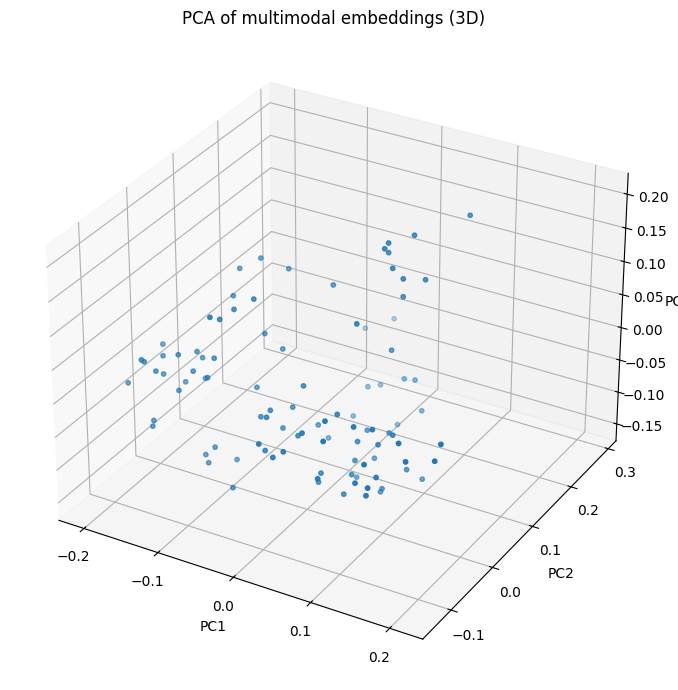

In [7]:
# PCA to 3D
_, _, v3 = torch.pca_lowrank(centered, q=3)
points_3d = centered @ v3[:, :3]

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(
    points_3d[:, 0].numpy(),
    points_3d[:, 1].numpy(),
    points_3d[:, 2].numpy(),
    s=10,
)
ax.set_title("PCA of multimodal embeddings (3D)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
plt.tight_layout()
plt.show()